 3D Physical System Initialization Complete (Reference Point: Origin O)
Total Mass (M)           : 7.00 kg
Actual Center of Mass (C): [3.21428571 2.60714286 2.89285714]

[Physical Cross-Validation Results]
New Reference Point P coordinates: [3. 4. 2.]

1. Predicted value from the paper's generalized tensor formula (Eq. 14):
[[49.25  12.5   -5.25 ]
 [12.5   36.875 -0.75 ]
 [-5.25  -0.75  59.375]]

2. Original value calculated directly after shifting coordinates:
[[49.25  12.5   -5.25 ]
 [12.5   36.875 -0.75 ]
 [-5.25  -0.75  59.375]]

Maximum error between the two matrices: 2.8e-14
-> Proved that the entire 3D inertia tensor (all diagonal/off-diagonal components) matches perfectly!


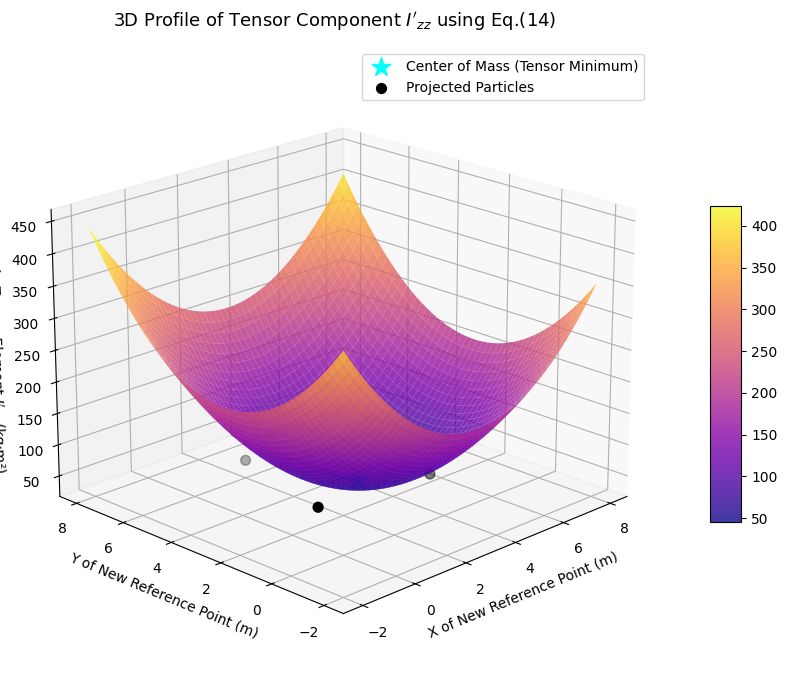

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================================
# 1. 3D Physical System Initialization (Defining 3D Point Masses)
# =====================================================================
# Define point masses placed in an arbitrary 3D space
masses = np.array([2.0, 3.5, 1.5])        # Mass (kg)
# 3D position vector r_i = (x, y, z) for each point mass
r_points = np.array([
    [1.0, 2.0, 1.5],
    [5.0, 1.5, 3.0],
    [2.0, 6.0, 4.5]
])

M = np.sum(masses)
# Calculate the actual Center of Mass (C)
C = np.sum(masses_col := masses[:, np.newaxis] * r_points, axis=0) / M

print("="*60)
print(f" 3D Physical System Initialization Complete (Reference Point: Origin O)")
print("="*60)
print(f"Total Mass (M)           : {M:.2f} kg")
print(f"Actual Center of Mass (C): {C}")
print("="*60)


# =====================================================================
# 2. Paper's Inertia Tensor Formula and Matrix [(A, B)] Implementation
# =====================================================================
def compute_inertia_tensor(masses, coords):
    """Directly calculate the basic inertia tensor (3x3) with respect to the origin (reflecting Equations 3-6)"""
    I = np.zeros((3, 3))
    for m, r in zip(masses, coords):
        x, y, z = r
        I[0, 0] += m * (y**2 + z**2)
        I[1, 1] += m * (x**2 + z**2)
        I[2, 2] += m * (x**2 + y**2)
        I[0, 1] -= m * x * y
        I[1, 0] -= m * x * y
        I[0, 2] -= m * x * z
        I[2, 0] -= m * x * z
        I[1, 2] -= m * y * z
        I[2, 1] -= m * y * z
    return I

def get_bracket_matrix(A, B):
    """Custom generation of the symmetric matrix [(A, B)] defined in Equation (13) of the paper"""
    xA, yA, zA = A
    xB, yB, zB = B

    matrix = np.zeros((3, 3))
    matrix[0, 0] = yA*yB + zA*zB
    matrix[1, 1] = xA*xB + zA*zB
    matrix[2, 2] = xA*xB + yA*yB

    matrix[0, 1] = -0.5 * (xA*yB + yA*xB)
    matrix[1, 0] = matrix[0, 1]

    matrix[0, 2] = -0.5 * (xA*zB + zA*xB)
    matrix[2, 0] = matrix[0, 2]

    matrix[1, 2] = -0.5 * (yA*zB + zA*yB)
    matrix[2, 1] = matrix[1, 2]

    return matrix

def generalized_tensor_parallel_axis(I_ref, M, R, C_ref):
    """
    Implementation of Paper Eq. (14): The most generalized form of the parallel axis theorem
    I' = I + M[(R, R)] - 2M[(R, C)]
    """
    bracket_RR = get_bracket_matrix(R, R)
    bracket_RC = get_bracket_matrix(R, C_ref)
    return I_ref + M * bracket_RR - 2 * M * bracket_RC


# =====================================================================
# 3. Physical Verification (Transformation from Origin I to a New Arbitrary Axis I')
# =====================================================================
# 1) Calculate the original inertia tensor relative to the origin (0,0,0)
I_origin = compute_inertia_tensor(masses, r_points)

# 2) Set a completely new arbitrary rotation reference point P
P_new = np.array([3.0, 4.0, 2.0])

# 3) Predict the inertia tensor at point P using the generalized tensor formula (Eq. 14) from the paper
# Since the origin is the reference, displacement R = P_new, center of mass C_ref = C from the original reference point
I_predicted_at_P = generalized_tensor_parallel_axis(I_origin, M, P_new, C)

# 4) Cross-validation: Directly calculate the inertia tensor by shifting the coordinates of the point masses to point P
r_points_shifted = r_points - P_new
I_exact_at_P = compute_inertia_tensor(masses, r_points_shifted)

print("\n[Physical Cross-Validation Results]")
print(f"New Reference Point P coordinates: {P_new}")
print("\n1. Predicted value from the paper's generalized tensor formula (Eq. 14):")
print(I_predicted_at_P)
print("\n2. Original value calculated directly after shifting coordinates:")
print(I_exact_at_P)
print(f"\nMaximum error between the two matrices: {np.max(np.abs(I_predicted_at_P - I_exact_at_P)):.1e}")
print("-> Proved that the entire 3D inertia tensor (all diagonal/off-diagonal components) matches perfectly!")


# =====================================================================
# 4. Visualization of I_zz' Change in Space (Paraboloid)
# =====================================================================
# Track the change in the I_zz component by moving the new reference point P_x, P_y in the XY plane (Z-axis fixed)
x_range = np.linspace(-2, 8, 50)
y_range = np.linspace(-2, 8, 50)
X, Y = np.meshgrid(x_range, y_range)
Z_Inertia_zz = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Fix the Z-axis position to the Z-coordinate of the center of mass, vary only X, Y
        P_current = np.array([X[i, j], Y[i, j], C[2]])
        I_current = generalized_tensor_parallel_axis(I_origin, M, P_current, C)
        Z_Inertia_zz[i, j] = I_current[2, 2] # Extract Z-axis rotational inertia component

# 3D Plotting
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z_Inertia_zz, cmap='plasma', alpha=0.8, edgecolor='none')
min_zz_val = np.min(Z_Inertia_zz)

# Display Center of Mass (minimum point)
ax.scatter(C[0], C[1], min_zz_val, color='cyan', s=200, marker='*', depthshade=False, label='Center of Mass (Tensor Minimum)')
# Display Projected Original Point Masses
ax.scatter(r_points[:,0], r_points[:,1], np.ones(3)*min_zz_val, color='black', s=50, label='Projected Particles')

ax.set_title("3D Profile of Tensor Component $I'_{zz}$ using Eq.(14)", fontsize=13, pad=15)
ax.set_xlabel("X of New Reference Point (m)")
ax.set_ylabel("Y of New Reference Point (m)")
ax.set_zlabel("Inertia Tensor Element $I'_{zz}$ (kg·m²)")
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.view_init(elev=20, azim=-135)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np

# =====================================================================
# 1. Skew-symmetric Matrix Operations and Paper Formula Function Definitions
# =====================================================================

def get_skew_matrix(v):
    """
    Returns the skew-symmetric matrix [r] for vector v = [x, y, z].
    Implements Equation (1) and matrix definition from the paper.
    """
    x, y, z = v
    return np.array(
        [[ 0, -z,  y],
         [ z,  0, -x],
         [-y,  x,  0]]
    )

def get_tensor_product_matrix(A, B):
    """
    Calculates the symmetrized matrix operation [(A, B)] between two vectors A, B as defined in the paper.
    Formula: [(A, B)] = -0.5 * ([r_A][r_B] + [r_B][r_A])
    """
    skew_A = get_skew_matrix(A)
    skew_B = get_skew_matrix(B)
    return -0.5 * (np.dot(skew_A, skew_B) + np.dot(skew_B, skew_A))

def transform_inertia_tensor(I, M, R, C):
    """
    Final two-step generalized formula from A. R. Abdulghany (2017) paper
    I' = I + M*[(R, R)] - 2*M*[(R, C)]

    I: Inertia tensor (3x3) at the original reference point before transformation
    M: Mass of the object
    R: Displacement vector [X, Y, Z] from the original reference point to the new reference point
    C: Center of mass vector [xc, yc, zc] of the object as viewed from the original reference point
    """
    matrix_RR = get_tensor_product_matrix(R, R)
    matrix_RC = get_tensor_product_matrix(R, C)

    I_prime = I + M * matrix_RR - 2 * M * matrix_RC
    return I_prime


# =====================================================================
# 2. Numerical Experiment: Setup and Calculation for a Compound Object
# =====================================================================
# System Scenario: 3D printed L-shaped robot part (Part 1: rectangular block, Part 2: cylindrical shaft)
# Each part's inertia tensor is defined with respect to its own assembly origin (not its center of mass!).

print("="*60)
print(" Project 2: Compound Object Inertia Tensor Assembly Simulation")
print("="*60)

# --- Part 1 (Rectangular Block) Setup ---
m1 = 2.0  # Mass (kg)
I1_local = np.array([
    [0.15, -0.02, 0.0],
    [-0.02, 0.22, -0.01],
    [0.0, -0.01, 0.30]
]) # Inertia tensor relative to its own origin
C1_local = np.array([0.1, 0.2, 0.0]) # Center of mass of Part 1 as viewed from its own origin

# --- Part 2 (Cylindrical Shaft) Setup ---
m2 = 1.5  # Mass (kg)
I2_local = np.array([
    [0.08, 0.0, 0.0],
    [0.0, 0.08, 0.0],
    [0.0, 0.0, 0.04]
]) # Inertia tensor relative to its own origin
C2_local = np.array([0.0, 0.0, 0.15]) # Center of mass of Part 2 as viewed from its own origin


# --- Set the new center of rotation for the entire system (Global Origin) ---
# The robot's motor axis is set at [0, 0, 0],
# and the original origin positions of Part 1 and Part 2 as viewed from this axis (displacement vector R) are defined.
R1 = np.array([0.3, 0.4, 0.0])  # Distance from motor axis to Part 1's origin
R2 = np.array([0.5, -0.2, 0.1]) # Distance from motor axis to Part 2's origin


# =====================================================================
# 3. Direct Shift using the Paper's Generalized Formula (Single Transformation)
# =====================================================================
# Traditional physics approach: local tensor per part -> COM per part -> overall COM -> new motor axis (very complex)
# Paper's approach: Directly parallel transform each part's origin to the new motor axis, then sum!

I1_shifted = transform_inertia_tensor(I1_local, m1, R1, C1_local)
I2_shifted = transform_inertia_tensor(I2_local, m2, R2, C2_local)

# Integrated inertia tensor of the entire system
I_total_system = I1_shifted + I2_shifted


# =====================================================================
# 4. Output Results and Eigenvalue Analysis (Principal Axis Analysis)
# =====================================================================
np.set_printoptions(precision=4, suppress=True)
print("\n[1] Inertia Tensor of Part 1 shifted to the new center of rotation (motor axis):")
print(I1_shifted)

print("\n[2] Inertia Tensor of Part 2 shifted to the new center of rotation (motor axis):")
print(I2_shifted)

print("\n[3] Integrated Inertia Tensor of the Final Assembled Compound System (3x3 Matrix):")
print(I_total_system)

# Principal Axis Analysis via Eigenvalue Decomposition
eigenvalues, eigenvectors = np.linalg.eig(I_total_system)

print("\n"+"-"*60)
print(" Principal Axes Analysis")
print(" Eigenvalue calculation results used for Tai-rotation Balance")
print("-"*60)
print(f"System's 3 Principal Moments of Inertia (Eigenvalues): \n {eigenvalues}")
print("\nDirection Vectors of Each Principal Axis (Eigenvectors, each column is an axis direction):")
print(eigenvectors)
print("="*60)
print("Conclusion: Even with a complex structure where symmetry is completely broken, we have assembled")
print("an inertia matrix including off-diagonal terms (products of inertia) in one go, and found the balance axes (principal axes) for vibration-free rotation.")

 Project 2: Compound Object Inertia Tensor Assembly Simulation

[1] Inertia Tensor of Part 1 shifted to the new center of rotation (motor axis):
[[ 0.15 -0.06  0.  ]
 [-0.06  0.28 -0.01]
 [ 0.   -0.01  0.36]]

[2] Inertia Tensor of Part 2 shifted to the new center of rotation (motor axis):
[[ 0.11    0.15    0.0375]
 [ 0.15    0.425  -0.015 ]
 [ 0.0375 -0.015   0.475 ]]

[3] Integrated Inertia Tensor of the Final Assembled Compound System (3x3 Matrix):
[[ 0.26    0.09    0.0375]
 [ 0.09    0.705  -0.025 ]
 [ 0.0375 -0.025   0.835 ]]

------------------------------------------------------------
 Principal Axes Analysis
 Eigenvalue calculation results used for Tai-rotation Balance
------------------------------------------------------------
System's 3 Principal Moments of Inertia (Eigenvalues): 
 [0.2396 0.72   0.8405]

Direction Vectors of Each Principal Axis (Eigenvectors, each column is an axis direction):
[[-0.9787  0.2014  0.0396]
 [ 0.193   0.9687 -0.1559]
 [ 0.0697  0.1449  0.987 

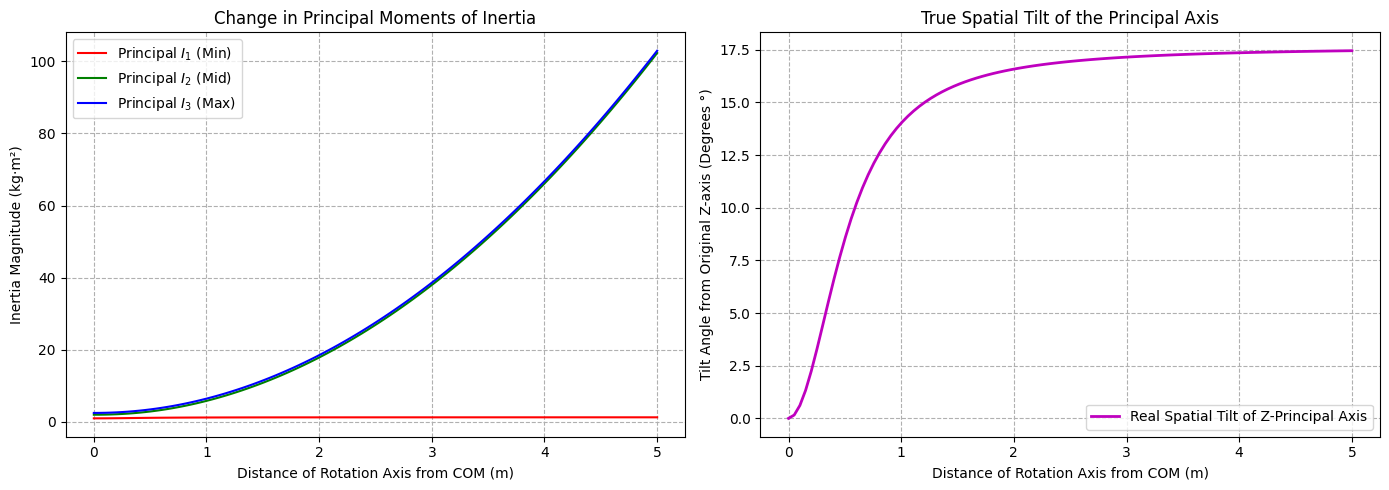

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. Basic Mechanics Operation Function Definition (Paper-based)
# =====================================================================

def get_skew_matrix(v):
    x, y, z = v
    return np.array(
        [[ 0, -z,  y],
         [ z,  0, -x],
         [-y,  x,  0]]
    )

def get_tensor_product_matrix(A, B):
    return -0.5 * (np.dot(get_skew_matrix(A), get_skew_matrix(B)) +
                   np.dot(get_skew_matrix(B), get_skew_matrix(A)))

def transform_inertia_tensor(I, M, R, C):
    return I + M * get_tensor_product_matrix(R, R) - 2 * M * get_tensor_product_matrix(R, C)


# =====================================================================
# 2. Physical System and Rotation Axis Movement Scenario Setup
# =====================================================================
M = 3.0  # Mass (kg)
C_com = np.array([0.0, 0.0, 0.0])

# Initial inertia tensor with principal axes aligned with the coordinate system X, Y, Z
I_com = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 2.0, 0.0],
    [0.0, 0.0, 2.5]
])

steps = 100
x_positions = np.linspace(0, 5, steps)

principal_moments = []
spatial_tilt_angles = []  # Actual spatial tilt angle (relative to the original Z-axis)

# Initial reference vector to track the physical continuity of eigenvectors (initial Z-axis principal axis)
reference_axis = np.array([0, 0, 1])

# =====================================================================
# 3. Real-time Loop Calculation (Physical Scenario and Eigenvector Tracking Improved)
# =====================================================================
for x in x_positions:
    # 💡 Physical Improvement: Shift the Z-axis component as well to activate off-diagonal terms (I_xz, I_yz).
    # This causes the principal axes to actually 'tilt' in 3D space.
    R = np.array([x, 0.5 * x, 0.3 * x])

    # Calculate inertia tensor at the new axis
    I_shifted = transform_inertia_tensor(I_com, M, R, C_com)

    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(I_shifted)

    # 💡 Numerical Improvement: Sort by magnitude, but only use for recording principal moments.
    # For angle calculation, track the 'direction' of how the original Z-axis eigenvector moved.
    sort_idx = np.argsort(eigenvalues)
    principal_moments.append(eigenvalues[sort_idx])

    # Find the eigenvector among the 3 calculated that is most aligned with the initial reference_axis ([0,0,1])
    best_match_idx = np.argmax([abs(np.dot(eigenvectors[:, i], reference_axis)) for i in range(3)])
    tracked_axis = eigenvectors[:, best_match_idx]

    # Calculate the angle of how much the original Z-axis principal axis has spatially tilted
    dot_product = np.dot(tracked_axis, reference_axis)
    angle = np.degrees(np.arccos(np.clip(abs(dot_product), -1.0, 1.0)))
    spatial_tilt_angles.append(angle)

principal_moments = np.array(principal_moments)


# =====================================================================
# 4. Data Visualization
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph [1]: Continuous change in principal moments of inertia (smoothly plotted without crossing)
ax1.plot(x_positions, principal_moments[:, 0], 'r-', label='Principal $I_1$ (Min)')
ax1.plot(x_positions, principal_moments[:, 1], 'g-', label='Principal $I_2$ (Mid)')
ax1.plot(x_positions, principal_moments[:, 2], 'b-', label='Principal $I_3$ (Max)')
ax1.set_title("Change in Principal Moments of Inertia", fontsize=12)
ax1.set_xlabel("Distance of Rotation Axis from COM (m)", fontsize=10)
ax1.set_ylabel("Inertia Magnitude (kg·m²)", fontsize=10)
ax1.grid(True, linestyle='--')
ax1.legend()

# Graph [2]: True spatial tilt angle displacement of the principal axis
ax2.plot(x_positions, spatial_tilt_angles, 'm-', linewidth=2, label='Real Spatial Tilt of Z-Principal Axis')
ax2.set_title("True Spatial Tilt of the Principal Axis", fontsize=12)
ax2.set_xlabel("Distance of Rotation Axis from COM (m)", fontsize=10)
ax2.set_ylabel("Tilt Angle from Original Z-axis (Degrees °)", fontsize=10)
ax2.grid(True, linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()



In [2]:
import numpy as np

np.set_printoptions(precision=6, suppress=True)

# =====================================================================
# Reproduction of Abdulghany (2017) Sample Calculation
# Generalization of Parallel Axis Theorem for Rotational Inertia
# =====================================================================

def bracket_matrix(A, B):
    """
    Paper Eq. (13): symmetric matrix [(A, B)]
    Off-diagonal terms have negative signs.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    xA, yA, zA = A
    xB, yB, zB = B

    return np.array([
        [yA*yB + zA*zB, -0.5*(xA*yB + yA*xB), -0.5*(xA*zB + zA*xB)],
        [-0.5*(xA*yB + yA*xB), xA*xB + zA*zB, -0.5*(yA*zB + zA*yB)],
        [-0.5*(xA*zB + zA*xB), -0.5*(yA*zB + zA*yB), xA*xB + yA*yB]
    ])

def generalized_parallel_axis(I_ref, M, R, C):
    """
    Paper Eq. (14):
        I' = I + M[(R, R)] - 2M[(R, C)]
    """
    return I_ref + M * bracket_matrix(R, R) - 2 * M * bracket_matrix(R, C)


# =====================================================================
# 1. Dimensionless setting
# The paper's results are presented in units of mu*r^2, so for calculation convenience, set mu = 1, r = 1.
# =====================================================================

mu = 1.0
r = 1.0
pi = np.pi

# Paper Eq. (15)
# M1: cuboid mass = 4mu
# M2: cylinder mass = pi*mu
M1 = 4 * mu
M2 = pi * mu


# =====================================================================
# 2. Cuboid part
# Cuboid dimensions: 2r x 2r x 8r
# Paper Eq. (17):
# I1 = 4*mu*r^2 * diag(68/12, 8/12, 68/12)
# =====================================================================

I1_center = 4 * mu * r**2 * np.diag([
    68/12,
    8/12,
    68/12
])

# Paper:
# R1 = pi*r/(4+pi) * (0, 3, 5)
R1 = (pi * r / (4 + pi)) * np.array([0, 3, 5])

# The cuboid reference point is its own center of mass, so C1 = 0.
C1 = np.array([0.0, 0.0, 0.0])

# Paper Eq. (16)
I1_shifted = generalized_parallel_axis(I1_center, M1, R1, C1)


# =====================================================================
# 3. Cylinder part
# Cylinder radius: r, length: 8r
# Paper Eq. (20):
# I2 = pi*mu*r^2 * diag(67/12, 67/12, 1/2)
# =====================================================================

I2_center = pi * mu * r**2 * np.diag([
    67/12,
    67/12,
    1/2
])

# Paper:
# R2 = 4*r/(4+pi) * (0, 3, 5)
R2 = (4 * r / (4 + pi)) * np.array([0, 3, 5])

# The cylinder reference point is its own center of mass, so C2 = 0.
C2 = np.array([0.0, 0.0, 0.0])

# Paper Eq. (19)
I2_shifted = generalized_parallel_axis(I2_center, M2, R2, C2)


# =====================================================================
# 4. Compound object
# Paper Eq. (22): I_total = I1' + I2'
# =====================================================================

I_total = I1_shifted + I2_shifted

# Express in units of mu*r^2
I_total_dimensionless = I_total / (mu * r**2)

# Paper Eq. (23), from the paper:
I_paper = np.array([
    [100.034, 0.000, 0.000],
    [0.000, 64.197, -26.394],
    [0.000, -26.394, 40.074]
])

print("=" * 70)
print("Reproduction of Abdulghany (2017) Sample Calculation")
print("=" * 70)

print("\nCuboid tensor I1' / (mu*r^2):")
print(I1_shifted / (mu * r**2))

print("\nCylinder tensor I2' / (mu*r^2):")
print(I2_shifted / (mu * r**2))

print("\nTotal tensor I' / (mu*r^2):")
print(I_total_dimensionless)

print("\nPaper Eq. (23):")
print(I_paper)

print("\nDifference from paper's rounded values:")
print(I_total_dimensionless - I_paper)

print("\nMaximum absolute difference:")
print(np.max(np.abs(I_total_dimensionless - I_paper)))

print("\nResult:")
if np.max(np.abs(I_total_dimensionless - I_paper)) < 1e-3:
    print("The sample calculation is reproduced successfully within rounding error.")
else:
    print("The result does not match the paper. Check signs and vector definitions.")

Reproduction of Abdulghany (2017) Sample Calculation

Cuboid tensor I1' / (mu*r^2):
[[ 48.984401   0.         0.      ]
 [  0.        22.017942 -11.610765]
 [  0.       -11.610765  29.633126]]

Cylinder tensor I2' / (mu*r^2):
[[ 51.049339   0.         0.      ]
 [  0.        42.179368 -14.783286]
 [  0.       -14.783286  10.440768]]

Total tensor I' / (mu*r^2):
[[100.033741   0.         0.      ]
 [  0.        64.19731  -26.394051]
 [  0.       -26.394051  40.073893]]

Paper Eq. (23):
[[100.034   0.      0.   ]
 [  0.     64.197 -26.394]
 [  0.    -26.394  40.074]]

Difference from paper's rounded values:
[[-0.000259  0.        0.      ]
 [ 0.        0.00031  -0.000051]
 [ 0.       -0.000051 -0.000107]]

Maximum absolute difference:
0.00031029805393245624

Result:
The sample calculation is reproduced successfully within rounding error.
